In [ ]:
# Importing necessary libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
# Load Dataset

df = pd.read_csv("Unemployment in India.csv")

# Display first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset: (768, 7)

Columns:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: fl

In [ ]:
# Remove extra spaces from column names

df.columns = df.columns.str.strip()

# Check missing values

print(df.isnull().sum())

# Remove missing values

df = df.dropna()

# Check duplicate records

print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates

df = df.drop_duplicates()

print("Final Shape:", df.shape)

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64
Duplicate Rows: 0
Final Shape: (740, 7)


In [ ]:
# Convert Date column into datetime format

df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


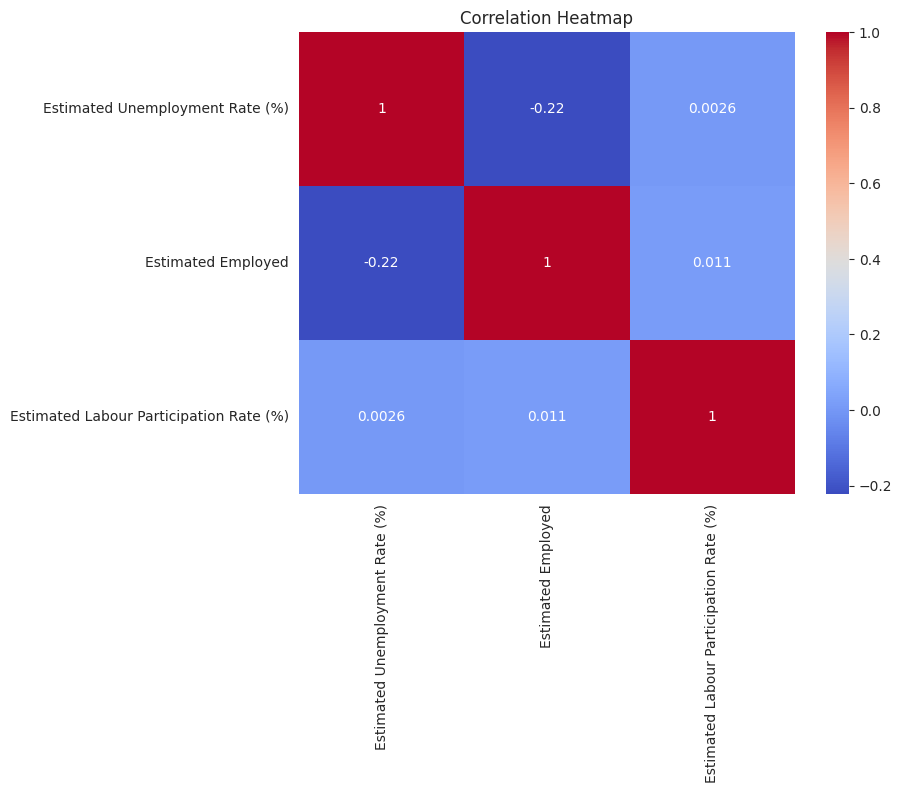

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

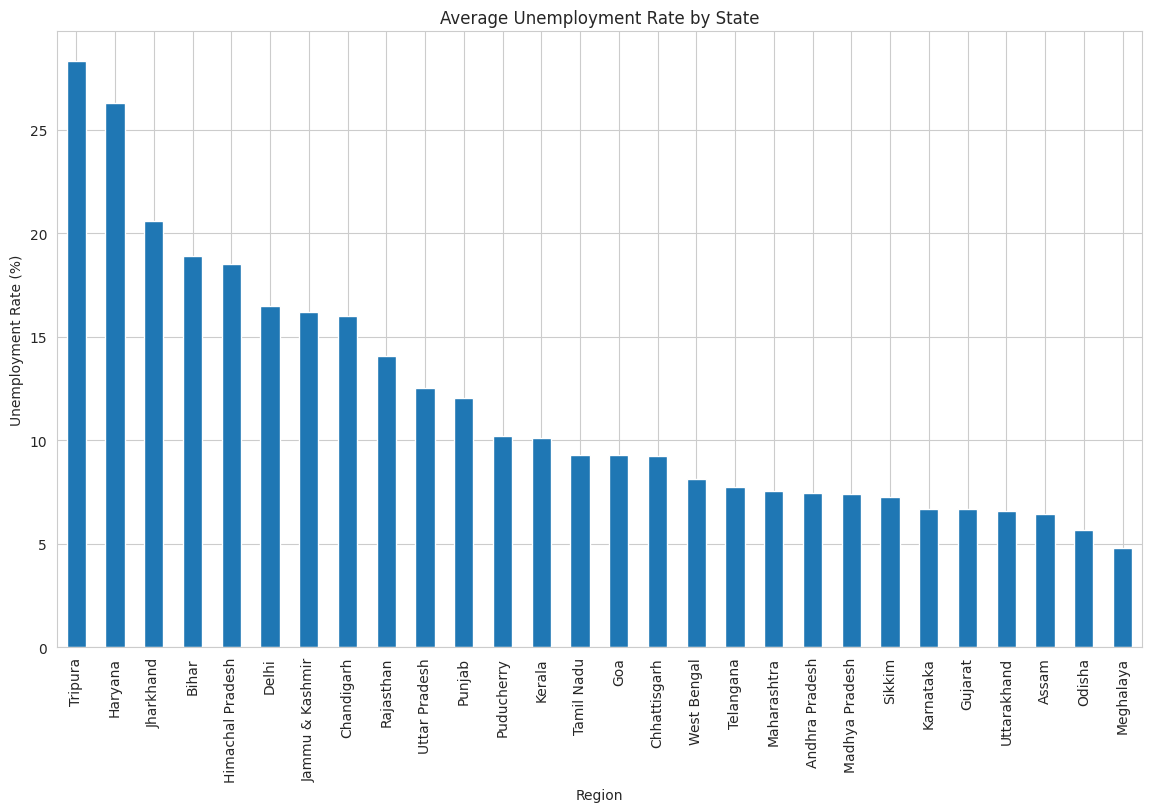

In [ ]:
state_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,8))

state_unemployment.plot(kind='bar')

plt.title("Average Unemployment Rate by State")
plt.ylabel("Unemployment Rate (%)")
plt.show()

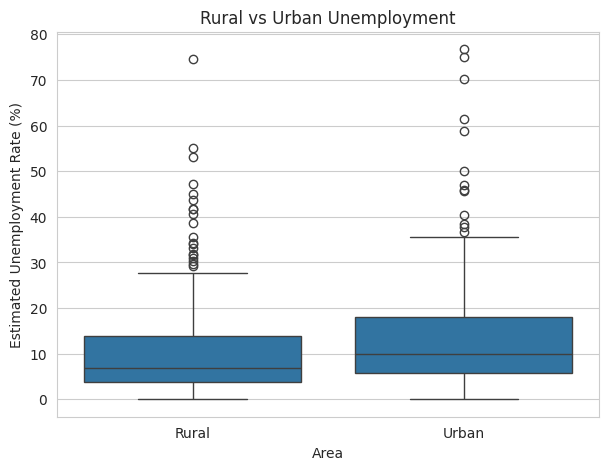

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Rural vs Urban Unemployment")
plt.show()

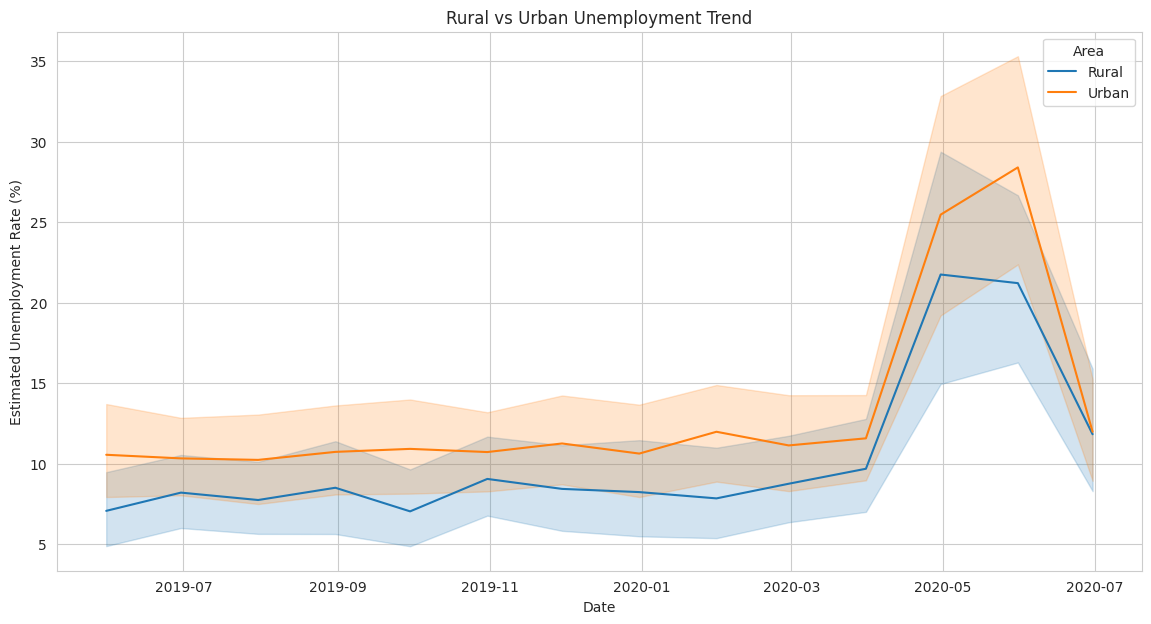

In [ ]:
plt.figure(figsize=(14,7))

sns.lineplot(
    data=df,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Area'
)

plt.title("Rural vs Urban Unemployment Trend")

plt.show()

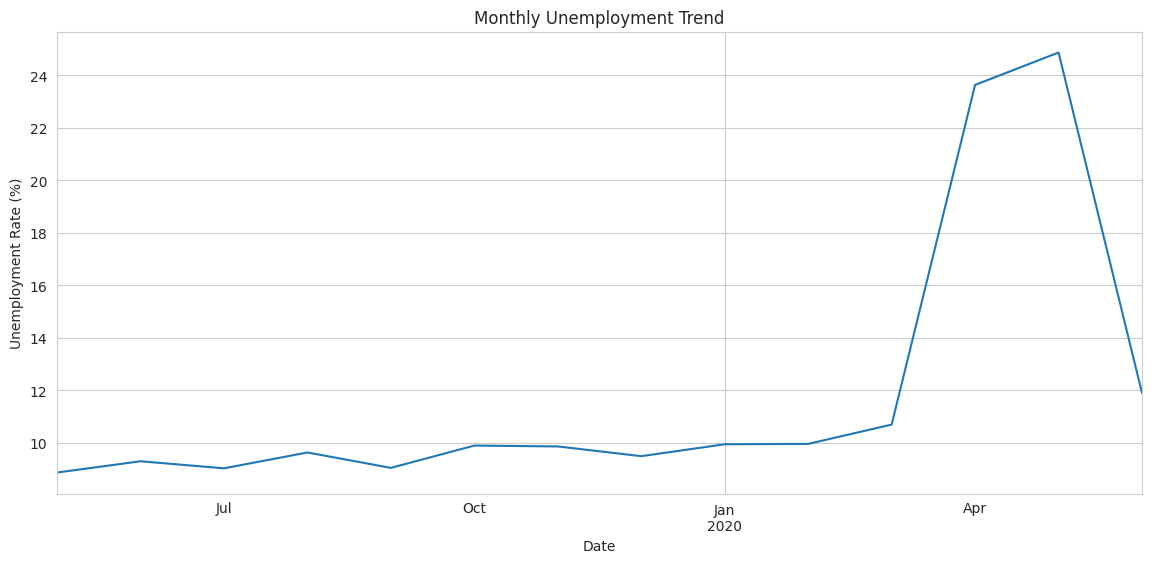

In [ ]:
monthly_trend = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
)

plt.figure(figsize=(14,6))

monthly_trend.plot()

plt.title("Monthly Unemployment Trend")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("Date")

plt.grid(True)

plt.show()

In [ ]:
# Creating Covid indicator

df['Covid_Period'] = np.where(
    df['Date'] >= '2020-03-01',
    'During Covid',
    'Before Covid'
)

covid_analysis = (
    df.groupby('Covid_Period')['Estimated Unemployment Rate (%)']
    .mean()
)

print(covid_analysis)

Covid_Period
Before Covid     9.509534
During Covid    17.774363
Name: Estimated Unemployment Rate (%), dtype: float64


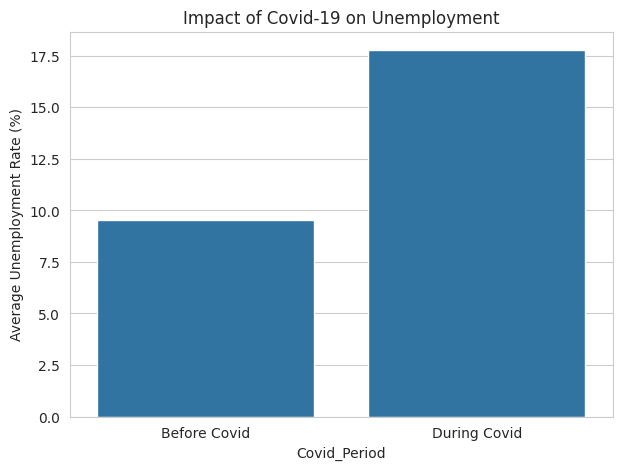

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=covid_analysis.index,
    y=covid_analysis.values
)

plt.title("Impact of Covid-19 on Unemployment")

plt.ylabel("Average Unemployment Rate (%)")

plt.show()

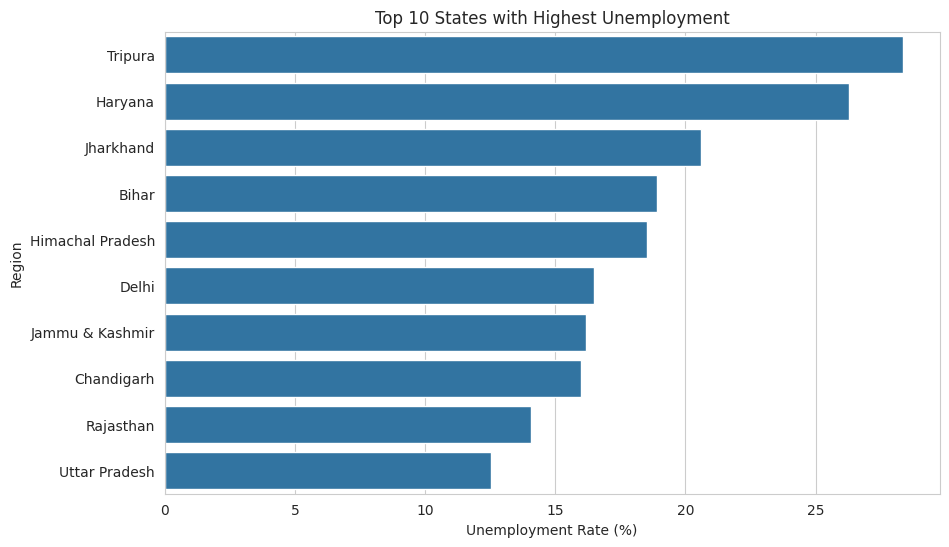

In [ ]:
top_states = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States with Highest Unemployment")

plt.xlabel("Unemployment Rate (%)")

plt.show()

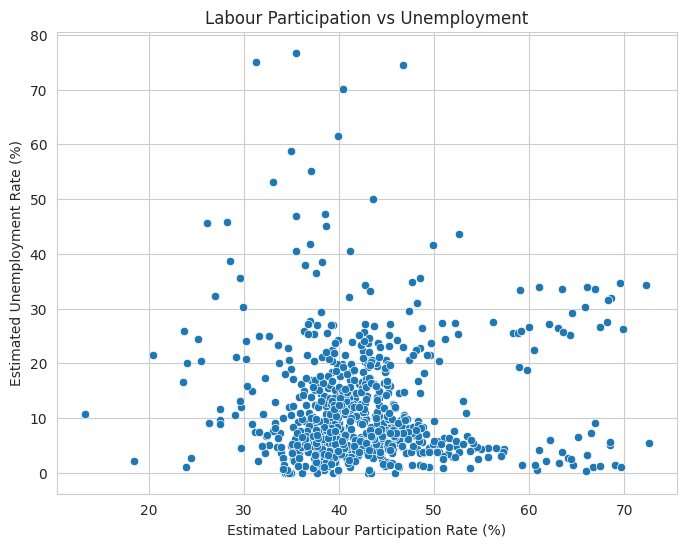

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Labour Participation vs Unemployment")

plt.show()

In [ ]:
print("KEY INSIGHTS")

print("\n1. Unemployment significantly increased during Covid-19.")

print("\n2. Certain states consistently recorded higher unemployment rates.")

print("\n3. Urban and rural areas show noticeable differences in unemployment patterns.")

print("\n4. Monthly trends indicate a sharp rise during lockdown periods.")

print("\n5. Labour participation rate exhibits varying relationships with unemployment.")

KEY INSIGHTS

1. Unemployment significantly increased during Covid-19.

2. Certain states consistently recorded higher unemployment rates.

3. Urban and rural areas show noticeable differences in unemployment patterns.

4. Monthly trends indicate a sharp rise during lockdown periods.

5. Labour participation rate exhibits varying relationships with unemployment.


In [ ]:

print("""
Conclusion:

The analysis reveals that Covid-19 had a substantial impact on unemployment in India.
Several states experienced significantly higher unemployment rates compared to others.
The findings suggest that targeted employment generation programs, skill development initiatives,
and economic recovery policies can help reduce unemployment and improve labour market stability.
""")


Conclusion:

The analysis reveals that Covid-19 had a substantial impact on unemployment in India.
Several states experienced significantly higher unemployment rates compared to others.
The findings suggest that targeted employment generation programs, skill development initiatives,
and economic recovery policies can help reduce unemployment and improve labour market stability.

